In [2]:
# Important imports 

import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


##  Chargement des données 

In [3]:
# 1. CHARGEMENT DES DONNÉES

def load_data(filepath):
    """
    Charge le fichier CSV contenant les éclairs.
    """
    df = pd.read_csv(filepath, parse_dates=['date'])
    df = df.sort_values('date').reset_index(drop=True)

    # FIX #7 : filtrer les éclairs intra-nuage de Pise en 2016

    # (système d'enregistrement différent — cf. documentation)
    mask_pise_2016_ic = (
        (df['airport'] == 'Pise') &
        (df['date'].dt.year == 2016) &
        (df['icloud'] == True)
    )
    n_filtered = mask_pise_2016_ic.sum()
    if n_filtered > 0:
        print(f"[load_data] Filtrage Pise 2016 IC : {n_filtered} éclairs supprimés.")
    df = df[~mask_pise_2016_ic].reset_index(drop=True)

    return df


##  CONSTRUCTION DES ALERTES À PARTIR DES ÉCLAIRS NUAGE-SOL

In [4]:


def build_alerts_from_cg(df, end_delay_min=30):
    """
    Crée une table des alertes à partir des éclairs nuage-sol (icloud=False)
    qui ont un airport_alert_id non nul.

    Pour chaque alerte (aéroport + airport_alert_id), on calcule :
        - start_time        : date du premier éclair nuage-sol de l'alerte
        - end_time          : date du dernier éclair nuage-sol
                              (is_last_lightning_cloud_ground=True)
        - alert_end_official: end_time + end_delay_min  (règle opérationnelle)
        - lightning_count   : nombre total d'éclairs (tous types) dans la fenêtre
        - cg_count          : nombre d'éclairs nuage-sol
    """
    cg_strikes = df[(df['icloud'] == False) & (df['airport_alert_id'].notna())].copy()
    cg_strikes['airport_alert_id'] = cg_strikes['airport_alert_id'].astype(int)

    alerts = []
    for (airport, alert_id), group in cg_strikes.groupby(['airport', 'airport_alert_id']):
        group = group.sort_values('date')
        start_time = group['date'].iloc[0]

        last_cg = group[group['is_last_lightning_cloud_ground'] == True]
        if len(last_cg) == 0:
            end_time = group['date'].iloc[-1]
        else:
            end_time = last_cg['date'].iloc[0]

        buffer = pd.Timedelta(minutes=5)
        mask = (
            (df['airport'] == airport) &
            (df['date'] >= start_time - buffer) &
            (df['date'] <= end_time + buffer)
        )
        all_in_alert = df[mask]

        alerts.append({
            'airport':            airport,
            'airport_alert_id':   alert_id,
            'start_time':         start_time,
            'end_time':           end_time,
            'alert_end_official': end_time + pd.Timedelta(minutes=end_delay_min),
            'lightning_count':    len(all_in_alert),
            'cg_count':           len(group),
        })

    return pd.DataFrame(alerts)

##  Construction des features 

In [5]:
def compute_features(past_strikes, current_time, airport):
    """
    Calcule les features à partir des éclairs passés et du contexte temporel.
    VERSION 2 — feature engineering enrichi.
    """
    feat = {'airport': airport}

    # ── Contexte temporel cyclique (invariant, calculé dans tous les cas) ──
    feat['month']        = current_time.month
    feat['hour']         = current_time.hour
    feat['month_sin']    = np.sin(2 * np.pi * current_time.month / 12)
    feat['month_cos']    = np.cos(2 * np.pi * current_time.month / 12)
    feat['hour_sin']     = np.sin(2 * np.pi * current_time.hour / 24)
    feat['hour_cos']     = np.cos(2 * np.pi * current_time.hour / 24)
    # Granularité fine : minutes depuis minuit (capte mieux les cycles diurnes)
    minutes_since_midnight = current_time.hour * 60 + current_time.minute
    feat['minute_of_day_sin'] = np.sin(2 * np.pi * minutes_since_midnight / 1440)
    feat['minute_of_day_cos'] = np.cos(2 * np.pi * minutes_since_midnight / 1440)

    # ── Cas sans aucun éclair passé ────────────────────────────────────────
    if len(past_strikes) == 0:
        nan_features = [
            'time_since_last', 'time_since_last_cg', 'time_since_last_ic',
            'time_since_first', 'time_since_peak',
            'std_interarrival', 'max_interarrival',
            'mean_dist', 'trend_dist', 'dist_recent_vs_mean',
            'angular_spread', 'azimuth_concentration',
            'prop_ic', 'mean_amplitude', 'std_amplitude', 'amplitude_trend',
            'ic_ratio_trend', 'rate_ratio_5_30', 'deceleration',
        ]
        for f in nan_features:
            feat[f] = np.nan

        zero_features = [
            'strike_count_5min', 'strike_count_10min', 'strike_count_30min',
            'rate_5min', 'rate_10min', 'rate_30min',
        ]
        for f in zero_features:
            feat[f] = 0

        return feat

    # ── Features temporelles de base ──────────────────────────────────────
    last = past_strikes.iloc[-1]
    feat['time_since_last'] = (
        current_time - last['date']
    ).total_seconds() / 60.0

    last_cg = past_strikes[past_strikes['icloud'] == False]
    feat['time_since_last_cg'] = (
        (current_time - last_cg.iloc[-1]['date']).total_seconds() / 60.0
        if len(last_cg) > 0 else np.nan
    )

    last_ic = past_strikes[past_strikes['icloud'] == True]
    feat['time_since_last_ic'] = (
        (current_time - last_ic.iloc[-1]['date']).total_seconds() / 60.0
        if len(last_ic) > 0 else np.nan
    )

    feat['time_since_first'] = (
        current_time - past_strikes.iloc[0]['date']
    ).total_seconds() / 60.0

    # ── Temps depuis le PIC d'activité ────────────────────────────────────
    # On découpe en fenêtres de 5min et on trouve celle avec le plus d'éclairs
    try:
        tmp = past_strikes.set_index('date').resample('5min').size()
        if len(tmp) > 0:
            peak_time = tmp.idxmax()
            feat['time_since_peak'] = (
                current_time - peak_time
            ).total_seconds() / 60.0
        else:
            feat['time_since_peak'] = np.nan
    except Exception:
        feat['time_since_peak'] = np.nan

    # ── Comptages & taux par fenêtre ──────────────────────────────────────
    counts = {}
    for window in [5, 10, 30]:
        mask = past_strikes['date'] >= current_time - pd.Timedelta(minutes=window)
        cnt  = int(mask.sum())
        feat[f'strike_count_{window}min'] = cnt
        feat[f'rate_{window}min']         = cnt / window
        counts[window] = cnt

    # ── Décélération : pente sur les 3 fenêtres ───────────────────────────
    # rate_5min, rate entre 5 et 10, rate entre 10 et 30
    r1 = counts[5]  / 5
    r2 = (counts[10] - counts[5])  / 5
    r3 = (counts[30] - counts[10]) / 20
    feat['deceleration'] = np.polyfit([0, 1, 2], [r1, r2, r3], 1)[0]
    # valeur négative = l'activité décroît → bon signal de fin d'orage

    # ── Ratio taux récent / taux global ───────────────────────────────────
    feat['rate_ratio_5_30'] = counts[5] / (counts[30] + 1e-6)
    # proche de 0 → l'activité récente est faible par rapport au passé

    # ── Inter-arrivées ────────────────────────────────────────────────────
    if len(past_strikes) >= 2:
        intervals = (
            past_strikes['date'].diff().dt.total_seconds().dropna() / 60.0
        )
        feat['std_interarrival'] = intervals.std()
        feat['max_interarrival'] = intervals.max()
        # grand max_interarrival = long silence déjà observé → fin probable
    else:
        feat['std_interarrival'] = np.nan
        feat['max_interarrival'] = np.nan

    # ── Spatiales ─────────────────────────────────────────────────────────
    feat['mean_dist'] = past_strikes['dist'].mean()

    recent = past_strikes.tail(min(5, len(past_strikes)))
    if len(recent) >= 2:
        slope = np.polyfit(np.arange(len(recent)), recent['dist'].values, 1)[0]
        feat['trend_dist'] = slope
        # positif → éclairs de plus en plus loin → orage qui s'éloigne
    else:
        feat['trend_dist'] = 0

    # Distance récente vs historique
    feat['dist_recent_vs_mean'] = recent['dist'].mean() - past_strikes['dist'].mean()
    # positif → éclairs récents plus loin que la moyenne → orage s'éloigne

    feat['angular_spread'] = past_strikes['azimuth'].std()

    # Concentration azimutale : proche de 1 = orage très directionnel
    feat['azimuth_concentration'] = float(
        np.sqrt(
            np.cos(np.deg2rad(past_strikes['azimuth'])).mean() ** 2 +
            np.sin(np.deg2rad(past_strikes['azimuth'])).mean() ** 2
        )
    )

    # ── Physiques ─────────────────────────────────────────────────────────
    feat['prop_ic']       = past_strikes['icloud'].mean()
    feat['mean_amplitude'] = past_strikes['amplitude'].mean()
    feat['std_amplitude']  = past_strikes['amplitude'].std()

    # Tendance amplitude sur les 10 derniers éclairs
    recent10 = past_strikes.tail(min(10, len(past_strikes)))
    if len(recent10) >= 2:
        feat['amplitude_trend'] = np.polyfit(
            np.arange(len(recent10)),
            recent10['amplitude'].values,
            1
        )[0]
        # négatif → amplitude décroissante → orage qui faiblit
    else:
        feat['amplitude_trend'] = 0

    # Ratio IC/CG récent vs global
    recent_ic  = past_strikes.tail(10)['icloud'].mean()
    global_ic  = past_strikes['icloud'].mean()
    feat['ic_ratio_trend'] = recent_ic / (global_ic + 1e-6)
    # < 1 → proportion IC récente plus faible → signal de fin d'orage

    return feat

## GÉNÉRATION DES ÉCHANTILLONS POUR UNE ALERTE


In [6]:

def get_strikes_for_alert(df, airport, start_time, end_time, buffer_min=5):
    """
    Récupère tous les éclairs (tous types) pour un aéroport donné entre
    start_time - buffer_min et end_time + buffer_min.
    """
    start = start_time - pd.Timedelta(minutes=buffer_min)
    end   = end_time   + pd.Timedelta(minutes=buffer_min)
    mask  = (df['airport'] == airport) & (df['date'] >= start) & (df['date'] <= end)
    return df[mask].copy().sort_values('date')


def generate_samples_for_alert(alert_df, df_full, horizon_min=30, freq_min=1, buffer_min=5):
    """
    Pour une alerte donnée (ligne de alerts_df), génère les échantillons
    temporels (un par minute de start_time à alert_end_official).

    FIX #1 : le buffer passé à get_strikes_for_alert est élargi à
              buffer_min + horizon_min pour couvrir toute la fenêtre future
              de chaque instant t de la grille, y compris les derniers instants
              proches de alert_end_official. Sans ça, les labels y sont
              faussement mis à 0 pour les ~horizon_min dernières minutes.
    """
    airport      = alert_df['airport']
    start        = alert_df['start_time']
    end_cg       = alert_df['end_time']
    end_official = alert_df['alert_end_official']

    # Buffer élargi : couvre end_cg + buffer_min + horizon_min
    strikes = get_strikes_for_alert(
        df_full, airport, start, end_cg,
        buffer_min=buffer_min + horizon_min   # ← correction
    )

    times   = pd.date_range(start, end_official, freq=f'{freq_min}min')
    samples = []

    for t in times:
        past   = strikes[strikes['date'] < t]
        future = strikes[
            (strikes['date'] >= t) &
            (strikes['date'] <  t + pd.Timedelta(minutes=horizon_min))
        ]
        y = 1 if len(future) > 0 else 0

        features = compute_features(past, t, airport)
        features['time']             = t
        features['y']                = y
        features['airport_alert_id'] = alert_df['airport_alert_id']
        samples.append(features)

    return pd.DataFrame(samples)


# Preparation de la dataset 

In [7]:
def prepare_dataset(df, alerts_df, horizon_min=30, freq_min=1, buffer_min=5):
    """
    Parcourt toutes les alertes et construit le dataset d'entraînement.
    horizon_min est transmis jusqu'à generate_samples_for_alert qui l'utilise
    à la fois pour définir la cible y ET pour élargir le buffer de récupération
    des éclairs (fix #1).
    """
    all_samples = []
    for idx, alert_row in alerts_df.iterrows():
        samples = generate_samples_for_alert(
            alert_row, df,
            horizon_min=horizon_min,
            freq_min=freq_min,
            buffer_min=buffer_min
        )
        all_samples.append(samples)
        if (idx + 1) % 10 == 0:
            print(f"Alertes traitées : {idx+1}/{len(alerts_df)}")
    return pd.concat(all_samples, ignore_index=True)


# Entrainement et code principal 

In [8]:
def train_model(X_train, y_train, X_val, y_val):
    """
    Entraîne un modèle XGBoost avec early stopping (API native Booster).
    """
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval   = xgb.DMatrix(X_val,   label=y_val)

    params = {
        'objective':        'binary:logistic',
        'max_depth':        6,
        'learning_rate':    0.05,
        'subsample':        0.8,
        'colsample_bytree': 0.8,
        'eval_metric':      'logloss',
        'seed':             42,
    }

    model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=[(dval, 'validation')],
        early_stopping_rounds=50,
        verbose_eval=100,
    )
    return model


In [9]:
# =============================================================================
# 5. EXÉCUTION PRINCIPALE
# =============================================================================

# ── 5.1 Chargement ────────────────────────────────────────────────────────────
print("Chargement des données...")
df = load_data('../../data/data_train_databattle2026/segment_alerts_all_airports_train.csv')

# ── 5.2 Construction des alertes ──────────────────────────────────────────────
print("Construction des alertes à partir des éclairs nuage-sol...")
alerts = build_alerts_from_cg(df)
print(f"Nombre d'alertes trouvées : {len(alerts)}")

# ── 5.3 Génération du dataset ─────────────────────────────────────────────────
print("Génération des échantillons temporels...")
HORIZON_MIN = 30   # paramètre central — utilisé pour y ET pour le buffer
dataset = prepare_dataset(df, alerts, horizon_min=HORIZON_MIN, freq_min=1)

# ── 5.4 Features & encodage ───────────────────────────────────────────────────
feature_cols = [
    col for col in dataset.columns
    if col not in ['time', 'y', 'airport', 'airport_alert_id']
]

le = LabelEncoder()
dataset['airport_encoded'] = le.fit_transform(dataset['airport'])
feature_cols.append('airport_encoded')

X = dataset[feature_cols].copy()
y = dataset['y']

# XGBoost gère les NaN nativement — fillna(-1) retiré (fix #10)
# Si vous tenez à imputer, préférez une valeur hors domaine par feature
# (ex. 9999 pour time_since_last, -1 pour prop_ic, etc.)

# ── 5.5 Split temporel (80 % train / 20 % val) ───────────────────────────────
alert_dates      = alerts[['airport', 'airport_alert_id', 'start_time']].copy()
dataset_with_date = dataset.merge(alert_dates, on=['airport', 'airport_alert_id'])

n_train       = int(0.8 * len(alerts))
alerts_sorted = alerts.sort_values('start_time').reset_index(drop=True)

train_alert_ids = alerts_sorted.iloc[:n_train][['airport', 'airport_alert_id']]
val_alert_ids   = alerts_sorted.iloc[n_train:][['airport', 'airport_alert_id']]

train_idx = (
    dataset_with_date[['airport', 'airport_alert_id']]
    .apply(tuple, axis=1)
    .isin(train_alert_ids.apply(tuple, axis=1))
)
val_idx = (
    dataset_with_date[['airport', 'airport_alert_id']]
    .apply(tuple, axis=1)
    .isin(val_alert_ids.apply(tuple, axis=1))
)

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]
print(f"Taille entraînement : {len(X_train)}, validation : {len(X_val)}")




Chargement des données...
[load_data] Filtrage Pise 2016 IC : 19404 éclairs supprimés.
Construction des alertes à partir des éclairs nuage-sol...
Nombre d'alertes trouvées : 2627
Génération des échantillons temporels...
Alertes traitées : 10/2627
Alertes traitées : 20/2627
Alertes traitées : 30/2627
Alertes traitées : 40/2627
Alertes traitées : 50/2627
Alertes traitées : 60/2627
Alertes traitées : 70/2627
Alertes traitées : 80/2627
Alertes traitées : 90/2627
Alertes traitées : 100/2627
Alertes traitées : 110/2627
Alertes traitées : 120/2627
Alertes traitées : 130/2627
Alertes traitées : 140/2627
Alertes traitées : 150/2627
Alertes traitées : 160/2627
Alertes traitées : 170/2627
Alertes traitées : 180/2627
Alertes traitées : 190/2627
Alertes traitées : 200/2627
Alertes traitées : 210/2627
Alertes traitées : 220/2627
Alertes traitées : 230/2627
Alertes traitées : 240/2627
Alertes traitées : 250/2627
Alertes traitées : 260/2627
Alertes traitées : 270/2627
Alertes traitées : 280/2627
Alert

In [22]:
# sauvegarde la liste des features
import joblib
joblib.dump(feature_cols, '../generated/feature_cols.pkl')

['../generated/feature_cols.pkl']

In [10]:
# =============================================================================
# 6. ENTRAÎNEMENT
# =============================================================================

print("Entraînement du modèle...")
model = train_model(X_train, y_train, X_val, y_val)


Entraînement du modèle...
[0]	validation-logloss:0.53762
[100]	validation-logloss:0.30984
[124]	validation-logloss:0.31183


In [11]:
# =============================================================================
# 7. ÉVALUATION CLASSIQUE
# =============================================================================

dval          = xgb.DMatrix(X_val)
y_pred_proba  = model.predict(dval)
y_pred        = (y_pred_proba >= 0.5).astype(int)

print("ROC AUC :", roc_auc_score(y_val, y_pred_proba))
print(classification_report(y_val, y_pred))


ROC AUC : 0.9144135772695776
              precision    recall  f1-score   support

           0       0.71      0.67      0.69      8124
           1       0.90      0.91      0.90     24913

    accuracy                           0.85     33037
   macro avg       0.80      0.79      0.80     33037
weighted avg       0.85      0.85      0.85     33037



In [13]:
# =============================================================================
# 8. SAUVEGARDE
# =============================================================================

model.save_model('../generated/modele_fin_orage.json')
joblib.dump(le, '../generated/label_encoder_airport.pkl')
print("Modèle et encodeur sauvegardés.")



Modèle et encodeur sauvegardés.


Top 10 features par gain :
                  feature        gain
8         time_since_last  994.232971
27      strike_count_5min  593.494446
25        rate_ratio_5_30  478.398804
30              rate_5min  389.574554
31             rate_10min  298.481262
28     strike_count_10min  237.651871
9      time_since_last_cg   61.773800
19  azimuth_concentration   47.842426
16             trend_dist   38.163498
33        airport_encoded   37.630810


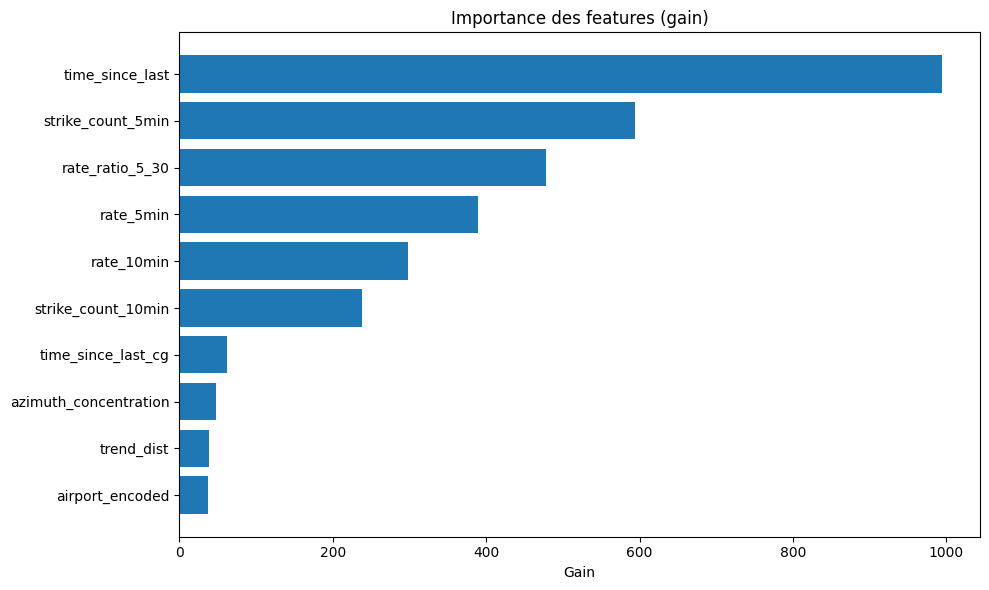

In [14]:
# =============================================================================
# 9. IMPORTANCE DES FEATURES
# =============================================================================

importance_gain = model.get_score(importance_type='gain')
df_imp = (
    pd.DataFrame({'feature': list(importance_gain.keys()),
                  'gain':    list(importance_gain.values())})
    .sort_values('gain', ascending=False)
)

print("Top 10 features par gain :")
print(df_imp.head(10))

plt.figure(figsize=(10, 6))
plt.barh(df_imp['feature'][:10], df_imp['gain'][:10])
plt.xlabel('Gain')
plt.title('Importance des features (gain)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()




In [15]:
# =============================================================================
# 10. CALCUL DU GAIN TEMPOREL OPÉRATIONNEL
# =============================================================================

# ── 10.1 Dernier éclair réel (tous types) par alerte ─────────────────────────
# FIX #5 : buffer élargi à horizon_min pour ne pas manquer les IC tardifs
def get_last_strike_for_alert(alert_row, df_full, buffer_min=5, horizon_min=30):
    strikes = get_strikes_for_alert(
        df_full,
        alert_row['airport'],
        alert_row['start_time'],
        alert_row['end_time'],
        buffer_min=buffer_min + horizon_min  
    )
    return strikes['date'].max()

alerts['last_strike_real'] = alerts.apply(
    lambda row: get_last_strike_for_alert(row, df, buffer_min=5, horizon_min=HORIZON_MIN),
    axis=1
)

# ── 10.2 Préparer val_data ────────────────────────────────────────────────────
val_data = dataset.loc[val_idx].copy().reset_index(drop=True)
val_data['proba'] = y_pred_proba

# Fusionner last_strike_real ET alert_end_official
val_data = val_data.merge(
    alerts[['airport', 'airport_alert_id', 'last_strike_real', 'alert_end_official']],
    on=['airport', 'airport_alert_id'],
    how='left'
)



Analyse pour seuil = 0.05...
Analyse pour seuil = 0.10...
Analyse pour seuil = 0.15...
Analyse pour seuil = 0.20...
Analyse pour seuil = 0.25...
Analyse pour seuil = 0.30...
Analyse pour seuil = 0.35...
Analyse pour seuil = 0.40...
Analyse pour seuil = 0.45...
Analyse pour seuil = 0.50...
Analyse pour seuil = 0.55...
Analyse pour seuil = 0.60...
Analyse pour seuil = 0.65...
Analyse pour seuil = 0.70...
Analyse pour seuil = 0.75...
Analyse pour seuil = 0.80...
    seuil  gain_moyen  taux_erreur  nb_alertes_anticipees  nb_sans_levee  \
0    0.05    0.000000     0.000000                      0            526   
1    0.10    4.979675     0.015209                     82            436   
2    0.15    6.754381     0.064639                    175            317   
3    0.20    8.555528     0.114068                    205            261   
4    0.25    9.896434     0.174905                    229            205   
5    0.30   11.224412     0.237643                    241            160   
6   

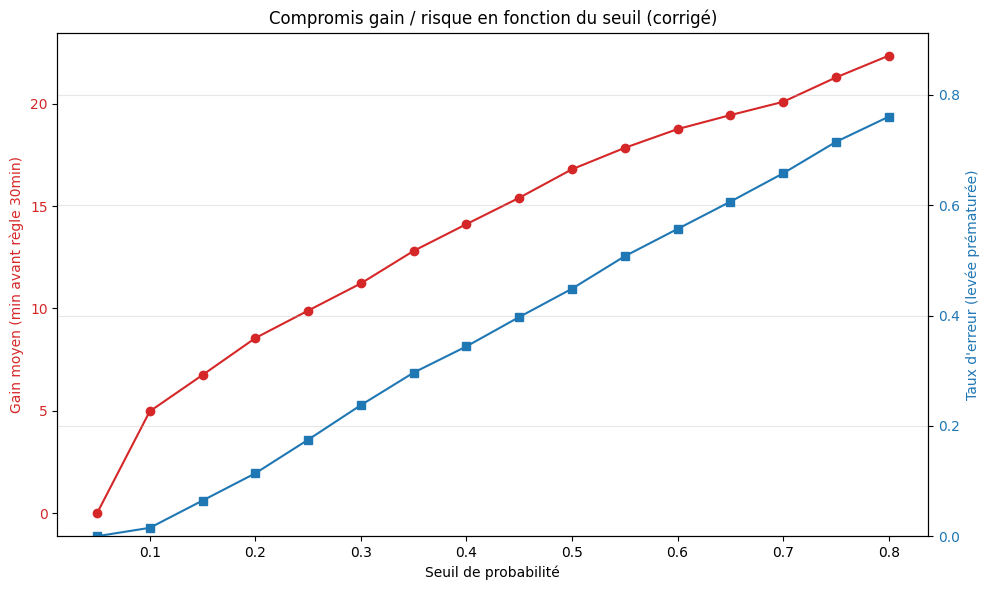

In [16]:
# =============================================================================
# 11. ANALYSE DU COMPROMIS GAIN / RISQUE EN FONCTION DU SEUIL (CORRIGÉE)
# =============================================================================

seuils    = np.arange(0.05, 0.81, 0.05)
resultats = []

for seuil in seuils:
    print(f"Analyse pour seuil = {seuil:.2f}...")
    gains        = []
    erreurs      = 0
    total_alertes = 0
    sans_levee   = 0

    # FIX #2 : groupby sur (airport, airport_alert_id)
    for (airport, alert_id), group in val_data.groupby(['airport', 'airport_alert_id']):
        total_alertes += 1
        group        = group.sort_values('time')
        last_strike  = group['last_strike_real'].iloc[0]
        end_official = group['alert_end_official'].iloc[0]

        # FIX #3 : chercher dans TOUT le groupe, pas seulement après last_strike
        first_safe = group[group['proba'] < seuil]

        if len(first_safe) == 0:
            sans_levee += 1
            continue

        lift_time = first_safe.iloc[0]['time']

        # FIX #3 : condition d'erreur correcte
        if lift_time <= last_strike:
            erreurs += 1
        else:
            # FIX #4 : gain = avance sur la règle des 30 minutes
            gain = (end_official - lift_time).total_seconds() / 60.0
            if gain > 0:
                gains.append(gain)
            else:
                sans_levee += 1  # modèle plus lent que la règle → pas de gain

    resultats.append({
        'seuil':                 seuil,
        'gain_moyen':            np.mean(gains) if gains else 0,
        'taux_erreur':           erreurs / total_alertes if total_alertes > 0 else 0,
        'nb_alertes_anticipees': len(gains),
        'nb_sans_levee':         sans_levee,
        'nb_erreurs':            erreurs,
    })

df_resultats = pd.DataFrame(resultats)
print(df_resultats)

# ── Tracé ─────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('Seuil de probabilité')
ax1.set_ylabel('Gain moyen (min avant règle 30min)', color=color)
ax1.plot(df_resultats['seuil'], df_resultats['gain_moyen'],
         color=color, marker='o', label='Gain moyen')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel("Taux d'erreur (levée prématurée)", color=color)
ax2.plot(df_resultats['seuil'], df_resultats['taux_erreur'],
         color=color, marker='s', label="Taux d'erreur")
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, max(df_resultats['taux_erreur'].max() * 1.2, 0.05))

plt.title("Compromis gain / risque en fonction du seuil (corrigé)")
plt.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [17]:
# # Récupérer les métadonnées pour la validation (dernier éclair réel et fin officielle)
# # On suppose que alerts contient déjà last_strike_real (calculé précédemment)
# # et alert_end_official (défini dans build_alerts_from_cg)

# # Fusionner les métadonnées avec les prédictions
# val_metadata = dataset_with_date.loc[val_idx, ['time', 'airport', 'airport_alert_id']].reset_index(drop=True)
# val_metadata = val_metadata.merge(
#     alerts[['airport', 'airport_alert_id', 'last_strike_real', 'alert_end_official']],
#     on=['airport', 'airport_alert_id'],
#     how='left'
# )

# # Créer le DataFrame avec les prédictions
# val_results_xgb = pd.DataFrame({
#     'time': val_metadata['time'],
#     'airport': val_metadata['airport'],
#     'airport_alert_id': val_metadata['airport_alert_id'],
#     'y': y_val.values,
#     'proba_xgb': y_pred_proba,
#     'last_strike_real': val_metadata['last_strike_real'],
#     'alert_end_official': val_metadata['alert_end_official']
# })

# # Sauvegarder
# val_results_xgb.to_csv('val_predictions_xgb.csv', index=False)
# print(f"Fichier val_predictions_xgb.csv sauvegardé avec {len(val_results_xgb)} lignes")

In [18]:
# =============================================================================
# GÉNÉRATION predictions.csv — format jury (données de test)
# =============================================================================
from tqdm import tqdm

# ── Charger les données de test du jury ──────────────────────────────────────
#  Remplace par le chemin exact de leur fichier
df_test     = load_data('../../data/dataset_test/dataset_set.csv')
alerts_test = build_alerts_from_cg(df_test)
print(f"{len(alerts_test)} alertes trouvées dans les données de test")

577 alertes trouvées dans les données de test


In [19]:
# ── Générer les prédictions ───────────────────────────────────────────────────
all_predictions = []

for _, alert_row in tqdm(alerts_test.iterrows(), total=len(alerts_test)):

    airport      = alert_row['airport']
    start        = alert_row['start_time']
    end_cg       = alert_row['end_time']
    end_official = alert_row['alert_end_official']
    airport_enc  = int(le.transform([airport])[0])

    strikes = get_strikes_for_alert(
        df_test, airport, start, end_cg,
        buffer_min=5 + HORIZON_MIN
    )

    for t in pd.date_range(start, end_official, freq='1min'):
        past  = strikes[strikes['date'] < t]
        feats = compute_features(past, t, airport)

        X_row = pd.DataFrame([feats]).drop(columns=['airport'], errors='ignore')
        X_row['airport_encoded'] = airport_enc
        X_row = X_row[feature_cols]

        dm    = xgb.DMatrix(X_row, feature_names=feature_cols)
        proba = float(model.predict(dm)[0])

        all_predictions.append({
            'airport':                  airport,
            'airport_alert_id':         int(alert_row['airport_alert_id']),
            'prediction_date':          t,
            'predicted_date_end_alert': t,
            'confidence':               round(1.0 - proba, 6),
        })

predictions_df = pd.DataFrame(all_predictions)


100%|██████████| 577/577 [02:29<00:00,  3.85it/s]


In [20]:
predictions_df.head()

,airport,airport_alert_id,prediction_date,predicted_date_end_alert,confidence
0,Ajaccio,532,2023-01-17 07:17:34+00:00,2023-01-17 07:17:34+00:00,0.119134
1,Ajaccio,532,2023-01-17 07:18:34+00:00,2023-01-17 07:18:34+00:00,0.389354
2,Ajaccio,532,2023-01-17 07:19:34+00:00,2023-01-17 07:19:34+00:00,0.420500
3,Ajaccio,532,2023-01-17 07:20:34+00:00,2023-01-17 07:20:34+00:00,0.252281
4,Ajaccio,532,2023-01-17 07:21:34+00:00,2023-01-17 07:21:34+00:00,0.254714


In [21]:
predictions_df.to_csv('../../data/dataset_test/our_predictions.csv', index=False)
print(f"{len(predictions_df)} lignes")
print(predictions_df.head())

38541 lignes
   airport  airport_alert_id           prediction_date  \
0  Ajaccio               532 2023-01-17 07:17:34+00:00   
1  Ajaccio               532 2023-01-17 07:18:34+00:00   
2  Ajaccio               532 2023-01-17 07:19:34+00:00   
3  Ajaccio               532 2023-01-17 07:20:34+00:00   
4  Ajaccio               532 2023-01-17 07:21:34+00:00   

   predicted_date_end_alert  confidence  
0 2023-01-17 07:17:34+00:00    0.119134  
1 2023-01-17 07:18:34+00:00    0.389354  
2 2023-01-17 07:19:34+00:00    0.420500  
3 2023-01-17 07:20:34+00:00    0.252281  
4 2023-01-17 07:21:34+00:00    0.254714  
